In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
import numpy as np
from pathlib import Path

plt.style.use('seaborn-v0_8-paper')

BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
PLOTS_DIR = BASE_DIR / 'plots' / 'tesis_data_section'
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

print(f"Directorio de salida: {PLOTS_DIR}")

Directorio de salida: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section


## 1. Arquitectura AE (Autoencoder Determinístico)

Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/arquitectura_AE.png


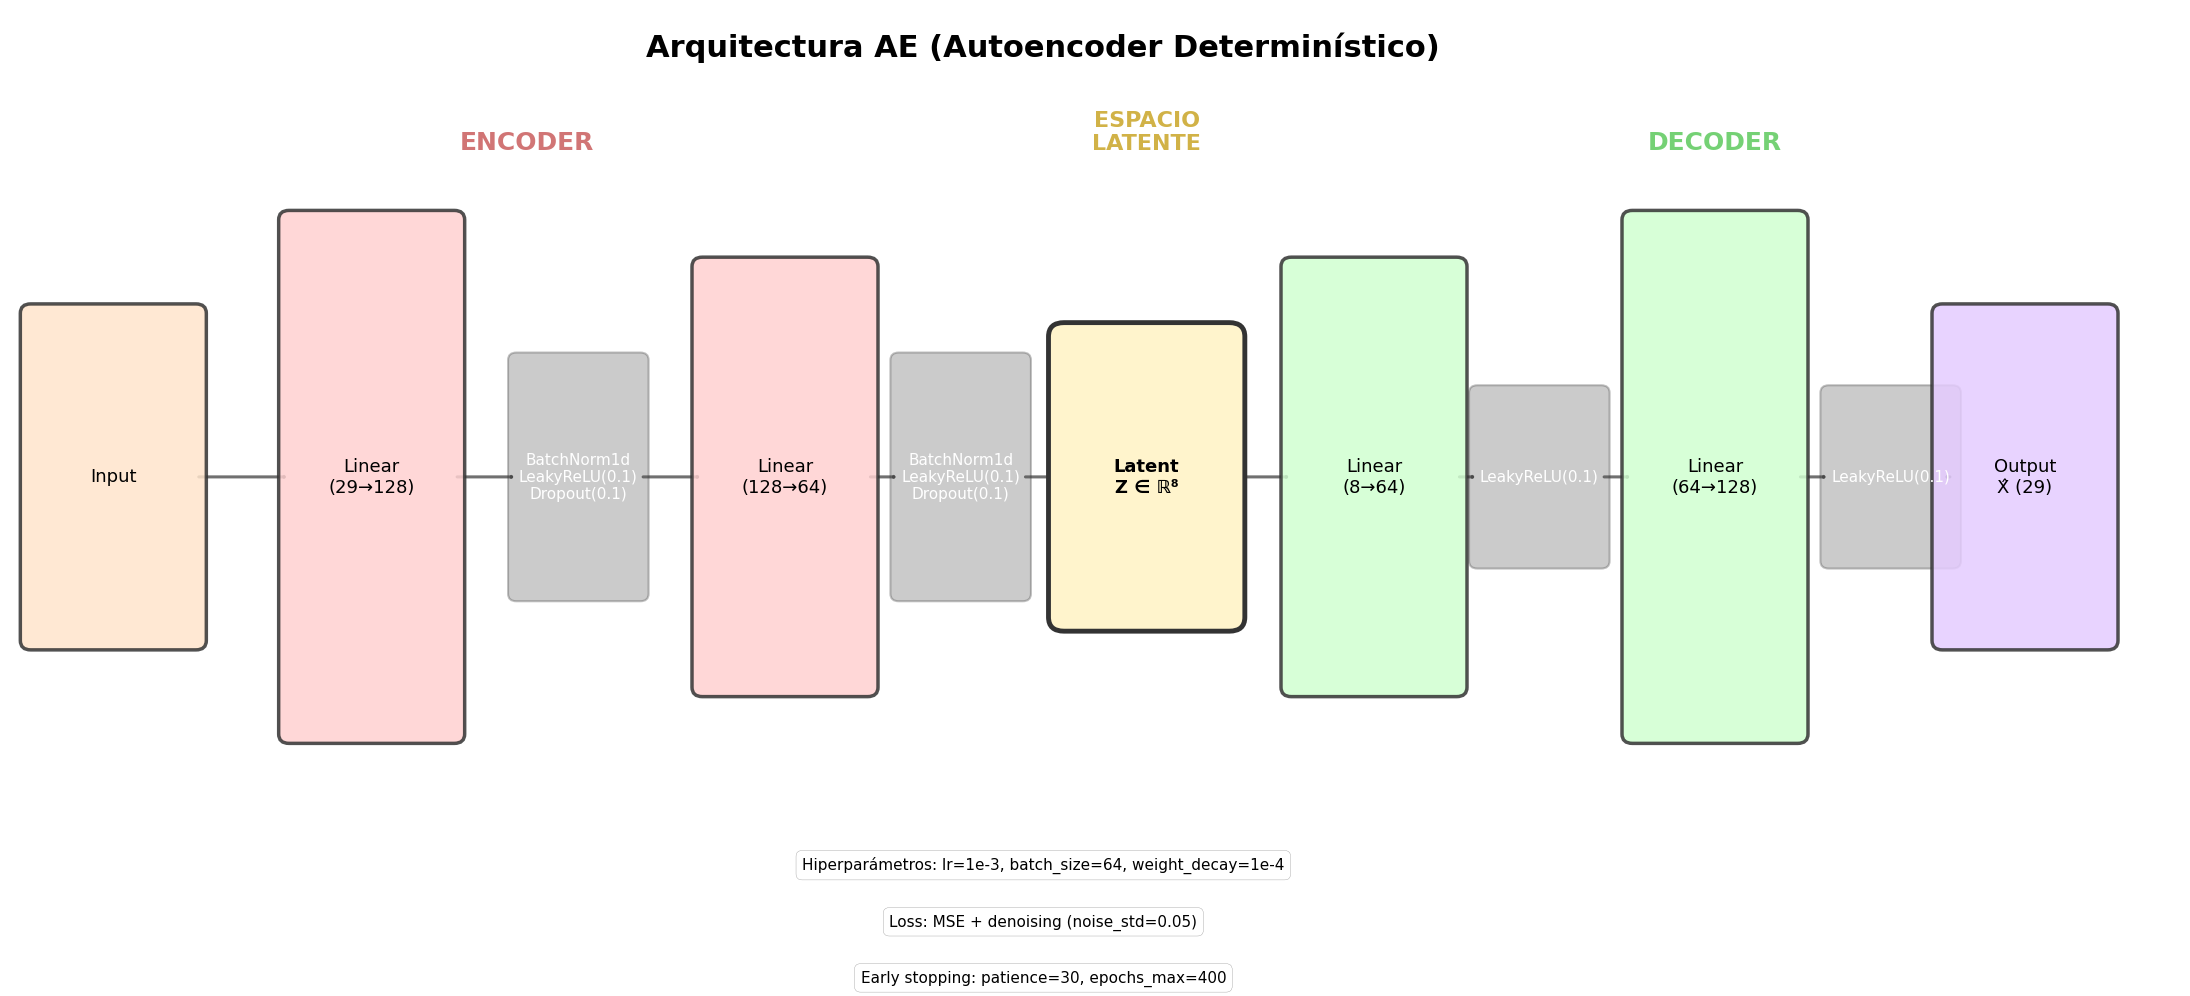

In [16]:
def draw_ae_architecture():
    """
    Dibuja arquitectura AE: 29→128→64→8→64→128→29
    Estilo: colores pasteles coherentes con notebook de visualización
    """
    fig, ax = plt.subplots(figsize=(22, 10))
    ax.set_xlim(0, 21)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Paleta de colores pasteles (coherente con tesis)
    color_input = '#FFE5CC'      # Pastel naranja suave
    color_encoder = '#FFD1D1'    # Pastel rojo
    color_latent = '#FFF4CC'     # Pastel amarillo
    color_decoder = '#D1FFD1'    # Pastel verde
    color_output = '#E5CCFF'     # Pastel violeta
    color_ops = '#555555'        # Gris oscuro para operaciones
    
    # Especificaciones arquitectura AE
    layers = [
        {'name': 'Input', 'dim': 29, 'x': 1, 'color': color_input, 'height': 3.5},
        {'name': 'Linear\n(29→128)', 'dim': 128, 'x': 3.5, 'color': color_encoder, 'height': 5.5},
        {'name': 'BatchNorm1d\nLeakyReLU(0.1)\nDropout(0.1)', 'dim': 128, 'x': 5.5, 'color': color_ops, 'height': 2.5, 'ops': True},
        {'name': 'Linear\n(128→64)', 'dim': 64, 'x': 7.5, 'color': color_encoder, 'height': 4.5},
        {'name': 'BatchNorm1d\nLeakyReLU(0.1)\nDropout(0.1)', 'dim': 64, 'x': 9.2, 'color': color_ops, 'height': 2.5, 'ops': True},
        {'name': 'Latent\nZ ∈ ℝ⁸', 'dim': 8, 'x': 11, 'color': color_latent, 'height': 3.0, 'bottleneck': True},
        {'name': 'Linear\n(8→64)', 'dim': 64, 'x': 13.2, 'color': color_decoder, 'height': 4.5},
        {'name': 'LeakyReLU(0.1)', 'dim': 64, 'x': 14.8, 'color': color_ops, 'height': 1.8, 'ops': True},
        {'name': 'Linear\n(64→128)', 'dim': 128, 'x': 16.5, 'color': color_decoder, 'height': 5.5},
        {'name': 'LeakyReLU(0.1)', 'dim': 128, 'x': 18.2, 'color': color_ops, 'height': 1.8, 'ops': True},
        {'name': 'Output\nX̂ (29)', 'dim': 29, 'x': 19.5, 'color': color_output, 'height': 3.5},
    ]
    
    # Dibujar capas
    boxes = []
    for layer in layers:
        x, y_center = layer['x'], 5
        h = layer['height']
        w = 1.2 if layer.get('ops', False) else 1.6
        
        # Estilo según tipo
        if layer.get('bottleneck', False):
            style = 'round,pad=0.15'
            lw = 3.5
            alpha = 1.0
        elif layer.get('ops', False):
            style = 'round,pad=0.08'
            lw = 1.5
            alpha = 0.3
        else:
            style = 'round,pad=0.1'
            lw = 2.5
            alpha = 0.85
        
        box = FancyBboxPatch(
            (x - w/2, y_center - h/2), w, h,
            boxstyle=style,
            facecolor=layer['color'],
            edgecolor='#333333',
            linewidth=lw,
            alpha=alpha,
            zorder=3
        )
        ax.add_patch(box)
        boxes.append((x, y_center, w, h, layer['name']))
        
        # Texto de la capa
        fontsize = 11 if layer.get('ops', False) else 13
        fontweight = 'bold' if layer.get('bottleneck', False) else 'normal'
        ax.text(x, y_center, layer['name'], 
                ha='center', va='center', 
                fontsize=fontsize, fontweight=fontweight,
                color='white' if layer.get('ops', False) else 'black',
                zorder=4)
    
    # Dibujar flechas entre capas
    for i in range(len(layers) - 1):
        x1, y1 = layers[i]['x'], 5
        x2, y2 = layers[i+1]['x'], 5
        w1 = 1.2 if layers[i].get('ops', False) else 1.6
        w2 = 1.2 if layers[i+1].get('ops', False) else 1.6
        
        arrow = FancyArrowPatch(
            (x1 + w1/2, y1), (x2 - w2/2, y2),
            arrowstyle='->,head_width=0.4,head_length=0.3',
            color='#333333',
            linewidth=2.2,
            alpha=0.7,
            zorder=2
        )
        ax.add_patch(arrow)
    
    # Anotaciones de secciones
    ax.text(5, 8.5, 'ENCODER', ha='center', fontsize=18, fontweight='bold', 
            color='#CC6666', alpha=0.9)
    ax.text(11, 8.5, 'ESPACIO\nLATENTE', ha='center', fontsize=16, fontweight='bold', 
            color='#CCAA33', alpha=0.9)
    ax.text(16.5, 8.5, 'DECODER', ha='center', fontsize=18, fontweight='bold', 
            color='#66CC66', alpha=0.9)
    
    # Título
    ax.text(10, 9.5, 'Arquitectura AE (Autoencoder Determinístico)', 
            ha='center', fontsize=22, fontweight='bold')
    
    # Detalles técnicos
    details = [
        'Hiperparámetros: lr=1e-3, batch_size=64, weight_decay=1e-4',
        'Loss: MSE + denoising (noise_std=0.05)',
        'Early stopping: patience=30, epochs_max=400',
    ]
    y_detail = 0.8
    for detail in details:
        ax.text(10, y_detail, detail, ha='center', fontsize=11, 
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor='gray', alpha=0.9))
        y_detail -= 0.6
    
    plt.tight_layout()
    return fig

fig_ae = draw_ae_architecture()
fig_ae.savefig(PLOTS_DIR / 'arquitectura_AE.png', dpi=300, bbox_inches='tight', facecolor='white')
fig_ae.savefig(PLOTS_DIR / 'arquitectura_AE.pdf', bbox_inches='tight', facecolor='white')
print(f"Guardado: {PLOTS_DIR / 'arquitectura_AE.png'}")
plt.show()

## 2. Arquitectura VAE (Variational Autoencoder)

Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/arquitectura_VAE.png


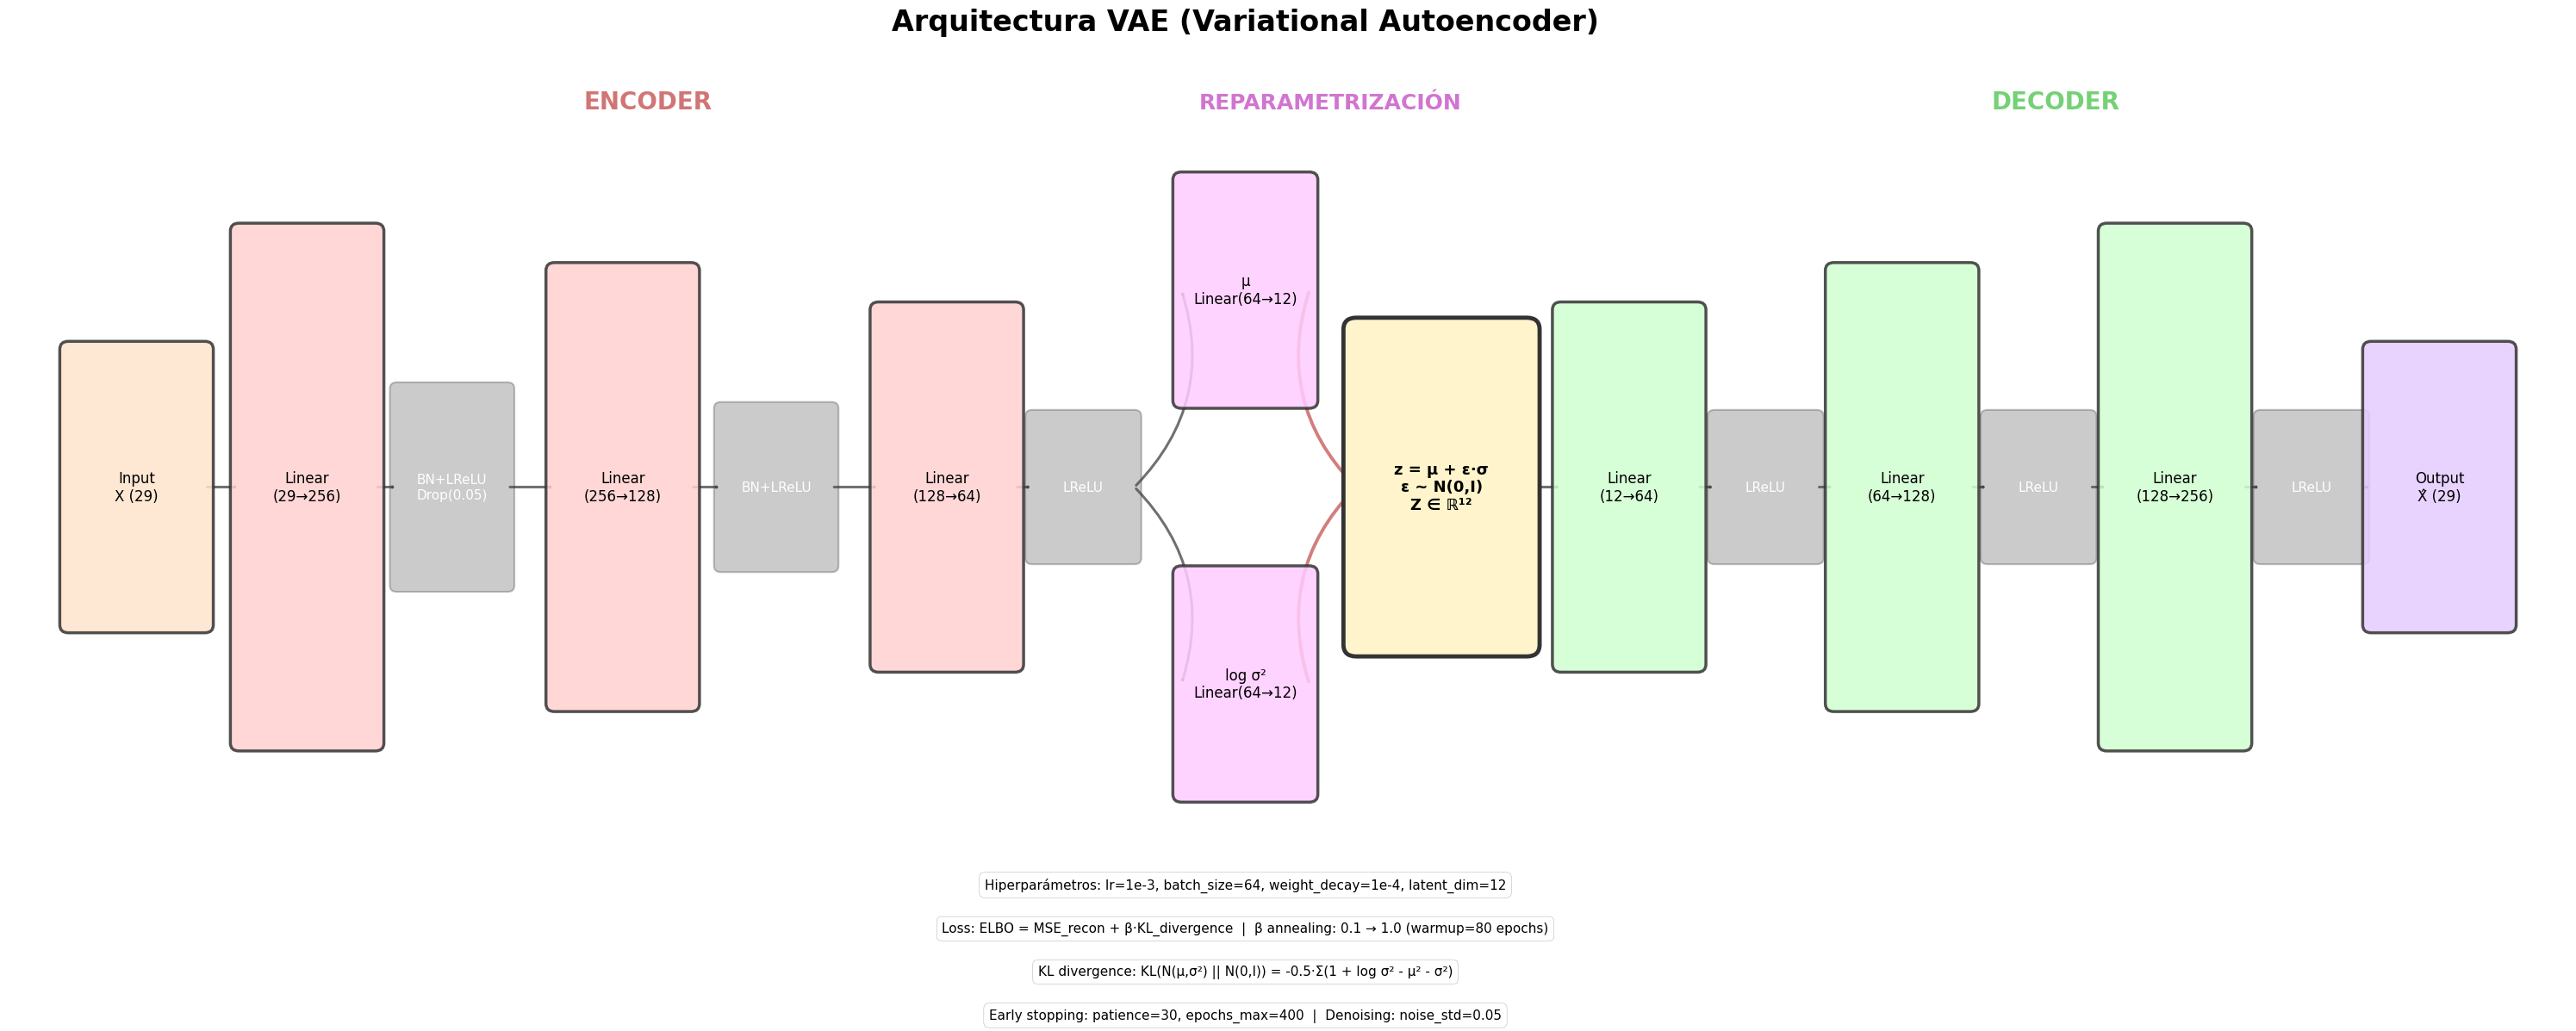

In [17]:
def draw_vae_architecture():
    """
    Dibuja arquitectura VAE: 29→256→128→64→(μ,logσ²)→Z(12)→64→128→256→29
    Incluye reparameterization trick
    """
    fig, ax = plt.subplots(figsize=(24, 12))
    ax.set_xlim(0, 24)
    ax.set_ylim(0, 12)
    ax.axis('off')
    
    # Paleta de colores
    color_input = '#FFE5CC'
    color_encoder = '#FFD1D1'
    color_latent = '#FFF4CC'
    color_decoder = '#D1FFD1'
    color_output = '#E5CCFF'
    color_ops = '#555555'
    color_special = '#FFCCFF'  # Para mu/logvar
    
    # Especificaciones arquitectura VAE
    layers = [
        {'name': 'Input\nX (29)', 'x': 1.5, 'y': 6, 'color': color_input, 'height': 3.5, 'width': 1.6},
        {'name': 'Linear\n(29→256)', 'x': 3.5, 'y': 6, 'color': color_encoder, 'height': 6.5, 'width': 1.6},
        {'name': 'BN+LReLU\nDropout', 'x': 5.2, 'y': 6, 'color': color_ops, 'height': 2.5, 'width': 1.2, 'ops': True},
        {'name': 'Linear\n(256→128)', 'x': 7.0, 'y': 6, 'color': color_encoder, 'height': 5.5, 'width': 1.6},
        {'name': 'BN+LReLU', 'x': 8.7, 'y': 6, 'color': color_ops, 'height': 2.0, 'width': 1.2, 'ops': True},
        {'name': 'Linear\n(128→64)', 'x': 10.5, 'y': 6, 'color': color_encoder, 'height': 4.5, 'width': 1.6},
        {'name': 'LReLU', 'x': 12.0, 'y': 6, 'color': color_ops, 'height': 1.8, 'width': 1.2, 'ops': True},
    ]
    
    # Reparametrización (bifurcación)
    mu_logvar = [
        {'name': 'Linear(64→12)\nμ', 'x': 13.5, 'y': 8, 'color': color_special, 'height': 2.5, 'width': 1.5},
        {'name': 'Linear(64→12)\nlog σ²', 'x': 13.5, 'y': 4, 'color': color_special, 'height': 2.5, 'width': 1.5},
    ]
    
    # Reparameterization trick
    reparam = {'name': 'z = μ + ε·σ\nε ~ N(0,I)', 'x': 15.5, 'y': 6, 'color': color_latent, 
               'height': 3.5, 'width': 1.8, 'bottleneck': True}
    
    # Decoder
    decoder = [
        {'name': 'Linear\n(12→64)', 'x': 17.5, 'y': 6, 'color': color_decoder, 'height': 4.5, 'width': 1.6},
        {'name': 'LReLU', 'x': 19.0, 'y': 6, 'color': color_ops, 'height': 1.8, 'width': 1.2, 'ops': True},
        {'name': 'Linear\n(64→128)', 'x': 20.5, 'y': 6, 'color': color_decoder, 'height': 5.5, 'width': 1.6},
        {'name': 'LReLU', 'x': 22.0, 'y': 6, 'color': color_ops, 'height': 1.8, 'width': 1.2, 'ops': True},
        {'name': 'Linear\n(128→256)', 'x': 23.8, 'y': 6, 'color': color_decoder, 'height': 6.5, 'width': 1.6},
        {'name': 'LReLU', 'x': 25.5, 'y': 6, 'color': color_ops, 'height': 1.8, 'width': 1.2, 'ops': True},
        {'name': 'Output\nX̂ (29)', 'x': 27.2, 'y': 6, 'color': color_output, 'height': 3.5, 'width': 1.6},
    ]
    
    def draw_layer(layer, ax):
        x, y = layer['x'], layer['y']
        h, w = layer['height'], layer['width']
        
        if layer.get('bottleneck', False):
            style, lw, alpha = 'round,pad=0.15', 3.5, 1.0
        elif layer.get('ops', False):
            style, lw, alpha = 'round,pad=0.08', 1.5, 0.3
        else:
            style, lw, alpha = 'round,pad=0.1', 2.5, 0.85
        
        box = FancyBboxPatch(
            (x - w/2, y - h/2), w, h,
            boxstyle=style, facecolor=layer['color'],
            edgecolor='#333333', linewidth=lw, alpha=alpha, zorder=3
        )
        ax.add_patch(box)
        
        fontsize = 11 if layer.get('ops', False) else 12
        fontweight = 'bold' if layer.get('bottleneck', False) else 'normal'
        ax.text(x, y, layer['name'], ha='center', va='center',
                fontsize=fontsize, fontweight=fontweight,
                color='white' if layer.get('ops', False) else 'black', zorder=4)
        return x, y, w, h
    
    # Dibujar encoder
    prev_x, prev_y, prev_w = None, None, None
    for layer in layers:
        x, y, w, h = draw_layer(layer, ax)
        if prev_x is not None:
            arrow = FancyArrowPatch(
                (prev_x + prev_w/2, prev_y), (x - w/2, y),
                arrowstyle='->,head_width=0.4,head_length=0.3',
                color='#333333', linewidth=2.2, alpha=0.7, zorder=2
            )
            ax.add_patch(arrow)
        prev_x, prev_y, prev_w = x, y, w
    
    # Dibujar bifurcación μ y logvar
    for ml in mu_logvar:
        x, y, w, h = draw_layer(ml, ax)
        arrow = FancyArrowPatch(
            (prev_x + prev_w/2, prev_y), (x - w/2, y),
            arrowstyle='->,head_width=0.4,head_length=0.3',
            color='#333333', linewidth=2.2, alpha=0.7, zorder=2,
            connectionstyle='arc3,rad=0.3' if ml['y'] > 6 else 'arc3,rad=-0.3'
        )
        ax.add_patch(arrow)
    
    # Dibujar reparametrización
    x_rep, y_rep, w_rep, h_rep = draw_layer(reparam, ax)
    for ml in mu_logvar:
        arrow = FancyArrowPatch(
            (ml['x'] + ml['width']/2, ml['y']), (x_rep - w_rep/2, y_rep),
            arrowstyle='->,head_width=0.4,head_length=0.3',
            color='#CC6666', linewidth=2.5, alpha=0.8, zorder=2,
            connectionstyle='arc3,rad=0.3' if ml['y'] > 6 else 'arc3,rad=-0.3'
        )
        ax.add_patch(arrow)
    
    # Dibujar decoder
    prev_x, prev_y, prev_w = x_rep, y_rep, w_rep
    for layer in decoder:
        x, y, w, h = draw_layer(layer, ax)
        arrow = FancyArrowPatch(
            (prev_x + prev_w/2, prev_y), (x - w/2, y),
            arrowstyle='->,head_width=0.4,head_length=0.3',
            color='#333333', linewidth=2.2, alpha=0.7, zorder=2
        )
        ax.add_patch(arrow)
        prev_x, prev_y, prev_w = x, y, w
    
    # Anotaciones
    ax.text(7.5, 10.5, 'ENCODER', ha='center', fontsize=20, fontweight='bold',
            color='#CC6666', alpha=0.9)
    ax.text(14.5, 10.5, 'REPARAMETRIZACIÓN', ha='center', fontsize=18, fontweight='bold',
            color='#CC66CC', alpha=0.9)
    ax.text(21.5, 10.5, 'DECODER', ha='center', fontsize=20, fontweight='bold',
            color='#66CC66', alpha=0.9)
    
    # Título
    ax.text(14, 11.5, 'Arquitectura VAE (Variational Autoencoder)',
            ha='center', fontsize=24, fontweight='bold')
    
    # Detalles técnicos
    details = [
        'Hiperparámetros: lr=1e-3, batch_size=64, weight_decay=1e-4, latent_dim=12',
        'Loss: ELBO = MSE + β·KL  |  β annealing: 0.1→1.0 (warmup=80 epochs)',
        'KL divergence: KL(N(μ,σ²) || N(0,I)) = -0.5·Σ(1 + log σ² - μ² - σ²)',
        'Early stopping: patience=30, epochs_max=400, denoising: noise_std=0.05',
    ]
    y_detail = 1.0
    for detail in details:
        ax.text(14, y_detail, detail, ha='center', fontsize=11,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                         edgecolor='gray', alpha=0.9))
        y_detail -= 0.6
    
    plt.tight_layout()
    return fig

# Ajustar límites para VAE (más ancha)
def draw_vae_architecture_fixed():
    fig, ax = plt.subplots(figsize=(30, 12))
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 12)
    ax.axis('off')
    
    # Paleta de colores
    color_input = '#FFE5CC'
    color_encoder = '#FFD1D1'
    color_latent = '#FFF4CC'
    color_decoder = '#D1FFD1'
    color_output = '#E5CCFF'
    color_ops = '#555555'
    color_special = '#FFCCFF'
    
    # Encoder
    layers = [
        {'name': 'Input\nX (29)', 'x': 1.5, 'y': 6, 'color': color_input, 'h': 3.5, 'w': 1.6},
        {'name': 'Linear\n(29→256)', 'x': 3.5, 'y': 6, 'color': color_encoder, 'h': 6.5, 'w': 1.6},
        {'name': 'BN+LReLU\nDrop(0.05)', 'x': 5.2, 'y': 6, 'color': color_ops, 'h': 2.5, 'w': 1.3, 'ops': True},
        {'name': 'Linear\n(256→128)', 'x': 7.2, 'y': 6, 'color': color_encoder, 'h': 5.5, 'w': 1.6},
        {'name': 'BN+LReLU', 'x': 9.0, 'y': 6, 'color': color_ops, 'h': 2.0, 'w': 1.3, 'ops': True},
        {'name': 'Linear\n(128→64)', 'x': 11.0, 'y': 6, 'color': color_encoder, 'h': 4.5, 'w': 1.6},
        {'name': 'LReLU', 'x': 12.6, 'y': 6, 'color': color_ops, 'h': 1.8, 'w': 1.2, 'ops': True},
    ]
    
    def draw_box(layer, ax):
        x, y = layer['x'], layer['y']
        h, w = layer['h'], layer['w']
        style = 'round,pad=0.15' if layer.get('bottleneck') else ('round,pad=0.08' if layer.get('ops') else 'round,pad=0.1')
        lw = 3.5 if layer.get('bottleneck') else (1.5 if layer.get('ops') else 2.5)
        alpha = 1.0 if layer.get('bottleneck') else (0.3 if layer.get('ops') else 0.85)
        
        box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle=style,
                            facecolor=layer['color'], edgecolor='#333333',
                            linewidth=lw, alpha=alpha, zorder=3)
        ax.add_patch(box)
        
        fs = 11 if layer.get('ops') else (13 if layer.get('bottleneck') else 12)
        fw = 'bold' if layer.get('bottleneck') else 'normal'
        col = 'white' if layer.get('ops') else 'black'
        ax.text(x, y, layer['name'], ha='center', va='center',
               fontsize=fs, fontweight=fw, color=col, zorder=4)
        return x, y, w
    
    # Dibujar encoder
    px, py, pw = None, None, None
    for L in layers:
        x, y, w = draw_box(L, ax)
        if px:
            ax.add_patch(FancyArrowPatch((px+pw/2, py), (x-w/2, y),
                        arrowstyle='->,head_width=0.4,head_length=0.3',
                        color='#333', lw=2.2, alpha=0.7, zorder=2))
        px, py, pw = x, y, w
    
    # μ y logvar
    mu = {'name': 'μ\nLinear(64→12)', 'x': 14.5, 'y': 8.5, 'color': color_special, 'h': 2.8, 'w': 1.5}
    lv = {'name': 'log σ²\nLinear(64→12)', 'x': 14.5, 'y': 3.5, 'color': color_special, 'h': 2.8, 'w': 1.5}
    
    x_mu, y_mu, w_mu = draw_box(mu, ax)
    x_lv, y_lv, w_lv = draw_box(lv, ax)
    
    ax.add_patch(FancyArrowPatch((px+pw/2, py), (x_mu-w_mu/2, y_mu),
                arrowstyle='->,head_width=0.4,head_length=0.3',
                color='#333', lw=2.2, alpha=0.7, zorder=2,
                connectionstyle='arc3,rad=0.3'))
    ax.add_patch(FancyArrowPatch((px+pw/2, py), (x_lv-w_lv/2, y_lv),
                arrowstyle='->,head_width=0.4,head_length=0.3',
                color='#333', lw=2.2, alpha=0.7, zorder=2,
                connectionstyle='arc3,rad=-0.3'))
    
    # Reparameterización
    rep = {'name': 'z = μ + ε·σ\nε ~ N(0,I)\nZ ∈ ℝ¹²', 'x': 16.8, 'y': 6, 'color': color_latent, 
           'h': 4.0, 'w': 2.0, 'bottleneck': True}
    x_rep, y_rep, w_rep = draw_box(rep, ax)
    
    ax.add_patch(FancyArrowPatch((x_mu+w_mu/2, y_mu), (x_rep-w_rep/2, y_rep),
                arrowstyle='->,head_width=0.5,head_length=0.4',
                color='#CC6666', lw=2.8, alpha=0.85, zorder=2,
                connectionstyle='arc3,rad=0.3'))
    ax.add_patch(FancyArrowPatch((x_lv+w_lv/2, y_lv), (x_rep-w_rep/2, y_rep),
                arrowstyle='->,head_width=0.5,head_length=0.4',
                color='#CC6666', lw=2.8, alpha=0.85, zorder=2,
                connectionstyle='arc3,rad=-0.3'))
    
    # Decoder
    decoder = [
        {'name': 'Linear\n(12→64)', 'x': 19.0, 'y': 6, 'color': color_decoder, 'h': 4.5, 'w': 1.6},
        {'name': 'LReLU', 'x': 20.6, 'y': 6, 'color': color_ops, 'h': 1.8, 'w': 1.2, 'ops': True},
        {'name': 'Linear\n(64→128)', 'x': 22.2, 'y': 6, 'color': color_decoder, 'h': 5.5, 'w': 1.6},
        {'name': 'LReLU', 'x': 23.8, 'y': 6, 'color': color_ops, 'h': 1.8, 'w': 1.2, 'ops': True},
        {'name': 'Linear\n(128→256)', 'x': 25.4, 'y': 6, 'color': color_decoder, 'h': 6.5, 'w': 1.6},
        {'name': 'LReLU', 'x': 27.0, 'y': 6, 'color': color_ops, 'h': 1.8, 'w': 1.2, 'ops': True},
        {'name': 'Output\nX̂ (29)', 'x': 28.5, 'y': 6, 'color': color_output, 'h': 3.5, 'w': 1.6},
    ]
    
    px, py, pw = x_rep, y_rep, w_rep
    for L in decoder:
        x, y, w = draw_box(L, ax)
        ax.add_patch(FancyArrowPatch((px+pw/2, py), (x-w/2, y),
                    arrowstyle='->,head_width=0.4,head_length=0.3',
                    color='#333', lw=2.2, alpha=0.7, zorder=2))
        px, py, pw = x, y, w
    
    # Labels de secciones
    ax.text(7.5, 10.8, 'ENCODER', ha='center', fontsize=20, fontweight='bold',
           color='#CC6666', alpha=0.9)
    ax.text(15.5, 10.8, 'REPARAMETRIZACIÓN', ha='center', fontsize=18, fontweight='bold',
           color='#CC66CC', alpha=0.9)
    ax.text(24, 10.8, 'DECODER', ha='center', fontsize=20, fontweight='bold',
           color='#66CC66', alpha=0.9)
    
    # Título
    ax.text(14.5, 11.8, 'Arquitectura VAE (Variational Autoencoder)',
           ha='center', fontsize=24, fontweight='bold')
    
    # Detalles
    details = [
        'Hiperparámetros: lr=1e-3, batch_size=64, weight_decay=1e-4, latent_dim=12',
        'Loss: ELBO = MSE_recon + β·KL_divergence  |  β annealing: 0.1 → 1.0 (warmup=80 epochs)',
        'KL divergence: KL(N(μ,σ²) || N(0,I)) = -0.5·Σ(1 + log σ² - μ² - σ²)',
        'Early stopping: patience=30, epochs_max=400  |  Denoising: noise_std=0.05',
    ]
    yd = 0.9
    for d in details:
        ax.text(14.5, yd, d, ha='center', fontsize=11,
               bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                        edgecolor='gray', alpha=0.9))
        yd -= 0.55
    
    plt.tight_layout()
    return fig

fig_vae = draw_vae_architecture_fixed()
fig_vae.savefig(PLOTS_DIR / 'arquitectura_VAE.png', dpi=300, bbox_inches='tight', facecolor='white')
fig_vae.savefig(PLOTS_DIR / 'arquitectura_VAE.pdf', bbox_inches='tight', facecolor='white')
print(f"Guardado: {PLOTS_DIR / 'arquitectura_VAE.png'}")
plt.show()

## 3. Diagrama Comparativo AE vs VAE (Simplificado)

Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/arquitectura_comparacion_AE_VAE.png


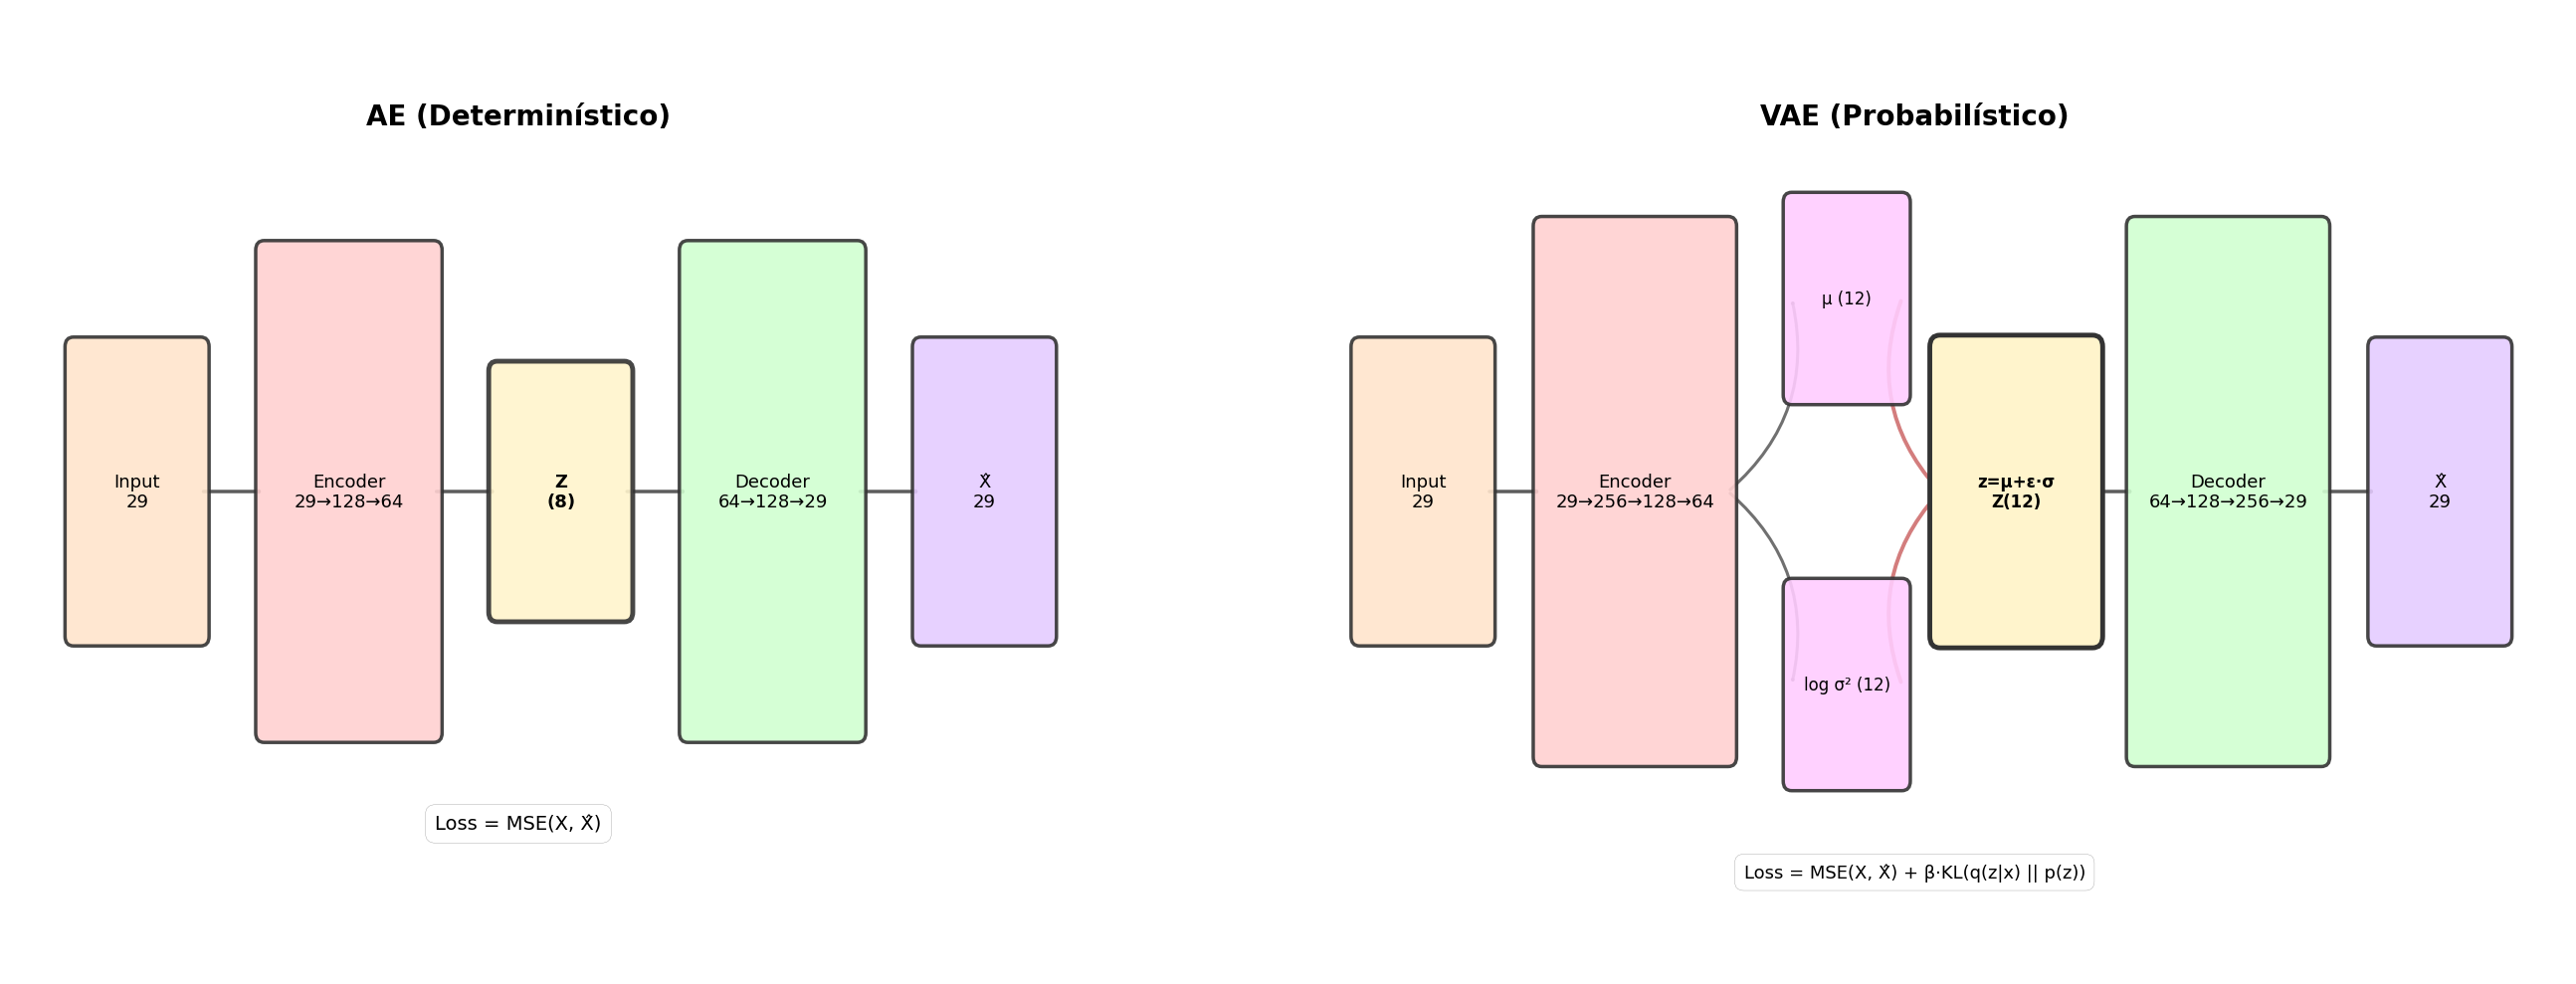

In [18]:
def draw_comparison():
    """
    Diagrama comparativo simplificado AE vs VAE lado a lado
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 10))
    
    for ax in [ax1, ax2]:
        ax.set_xlim(-0.5, 14.5)
        ax.set_ylim(0, 10)
        ax.axis('off')
    
    # Colores
    c_in = '#FFE5CC'
    c_enc = '#FFD1D1'
    c_lat = '#FFF4CC'
    c_dec = '#D1FFD1'
    c_out = '#E5CCFF'
    
    # AE simplificado
    ae_layers = [
        {'name': 'Input\n29', 'x': 1, 'y': 5, 'c': c_in, 'h': 3, 'w': 1.5},
        {'name': 'Encoder\n29→128→64', 'x': 3.5, 'y': 5, 'c': c_enc, 'h': 5, 'w': 2.0},
        {'name': 'Z\n(8)', 'x': 6, 'y': 5, 'c': c_lat, 'h': 2.5, 'w': 1.5, 'bt': True},
        {'name': 'Decoder\n64→128→29', 'x': 8.5, 'y': 5, 'c': c_dec, 'h': 5, 'w': 2.0},
        {'name': 'X̂\n29', 'x': 11, 'y': 5, 'c': c_out, 'h': 3, 'w': 1.5},
    ]
    
    prev = None
    for L in ae_layers:
        x, y, w, h = L['x'], L['y'], L['w'], L['h']
        lw = 3.5 if L.get('bt') else 2.5
        box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle='round,pad=0.1',
                            facecolor=L['c'], edgecolor='#333', linewidth=lw,
                            alpha=0.9, zorder=3)
        ax1.add_patch(box)
        ax1.text(x, y, L['name'], ha='center', va='center', fontsize=13,
                fontweight='bold' if L.get('bt') else 'normal', zorder=4)
        
        if prev:
            ax1.add_patch(FancyArrowPatch((prev[0]+prev[2]/2, prev[1]), (x-w/2, y),
                         arrowstyle='->,head_width=0.5,head_length=0.4',
                         color='#333', lw=2.5, alpha=0.8, zorder=2))
        prev = (x, y, w, h)
    
    ax1.text(5.5, 8.8, 'AE (Determinístico)', ha='center', fontsize=20, fontweight='bold')
    ax1.text(5.5, 1.5, 'Loss = MSE(X, X̂)', ha='center', fontsize=14,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))
    
    # VAE simplificado
    vae_base = [
        {'name': 'Input\n29', 'x': 1, 'y': 5, 'c': c_in, 'h': 3, 'w': 1.5},
        {'name': 'Encoder\n29→256→128→64', 'x': 3.5, 'y': 5, 'c': c_enc, 'h': 5.5, 'w': 2.2},
    ]
    
    mu_lv = [
        {'name': 'μ (12)', 'x': 6, 'y': 7, 'c': '#FFCCFF', 'h': 2, 'w': 1.3},
        {'name': 'log σ² (12)', 'x': 6, 'y': 3, 'c': '#FFCCFF', 'h': 2, 'w': 1.3},
    ]
    
    rep = {'name': 'z=μ+ε·σ\nZ(12)', 'x': 8, 'y': 5, 'c': c_lat, 'h': 3, 'w': 1.8, 'bt': True}
    
    dec = [
        {'name': 'Decoder\n64→128→256→29', 'x': 10.5, 'y': 5, 'c': c_dec, 'h': 5.5, 'w': 2.2},
        {'name': 'X̂\n29', 'x': 13, 'y': 5, 'c': c_out, 'h': 3, 'w': 1.5},
    ]
    
    # Dibujar VAE
    prev = None
    for L in vae_base:
        x, y, w, h = L['x'], L['y'], L['w'], L['h']
        box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle='round,pad=0.1',
                            facecolor=L['c'], edgecolor='#333', linewidth=2.5,
                            alpha=0.9, zorder=3)
        ax2.add_patch(box)
        ax2.text(x, y, L['name'], ha='center', va='center', fontsize=13, zorder=4)
        
        if prev:
            ax2.add_patch(FancyArrowPatch((prev[0]+prev[2]/2, prev[1]), (x-w/2, y),
                         arrowstyle='->,head_width=0.5,head_length=0.4',
                         color='#333', lw=2.5, alpha=0.8, zorder=2))
        prev = (x, y, w, h)
    
    # μ y logvar
    for ml in mu_lv:
        x, y, w, h = ml['x'], ml['y'], ml['w'], ml['h']
        box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle='round,pad=0.1',
                            facecolor=ml['c'], edgecolor='#333', linewidth=2.5,
                            alpha=0.9, zorder=3)
        ax2.add_patch(box)
        ax2.text(x, y, ml['name'], ha='center', va='center', fontsize=12, zorder=4)
        
        ax2.add_patch(FancyArrowPatch((prev[0]+prev[2]/2, prev[1]), (x-w/2, y),
                     arrowstyle='->,head_width=0.4,head_length=0.3',
                     color='#333', lw=2.2, alpha=0.7, zorder=2,
                     connectionstyle='arc3,rad=0.3' if y > 5 else 'arc3,rad=-0.3'))
    
    # Reparametrización
    x, y, w, h = rep['x'], rep['y'], rep['w'], rep['h']
    box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle='round,pad=0.12',
                        facecolor=rep['c'], edgecolor='#333', linewidth=3.5,
                        alpha=1.0, zorder=3)
    ax2.add_patch(box)
    ax2.text(x, y, rep['name'], ha='center', va='center', fontsize=12, fontweight='bold', zorder=4)
    
    for ml in mu_lv:
        ax2.add_patch(FancyArrowPatch((ml['x']+ml['w']/2, ml['y']), (x-w/2, y),
                     arrowstyle='->,head_width=0.5,head_length=0.4',
                     color='#CC6666', lw=2.8, alpha=0.85, zorder=2,
                     connectionstyle='arc3,rad=0.3' if ml['y'] > 5 else 'arc3,rad=-0.3'))
    
    # Decoder
    prev = (x, y, w, h)
    for L in dec:
        x, y, w, h = L['x'], L['y'], L['w'], L['h']
        box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle='round,pad=0.1',
                            facecolor=L['c'], edgecolor='#333', linewidth=2.5,
                            alpha=0.9, zorder=3)
        ax2.add_patch(box)
        ax2.text(x, y, L['name'], ha='center', va='center', fontsize=13, zorder=4)
        
        ax2.add_patch(FancyArrowPatch((prev[0]+prev[2]/2, prev[1]), (x-w/2, y),
                     arrowstyle='->,head_width=0.5,head_length=0.4',
                     color='#333', lw=2.5, alpha=0.8, zorder=2))
        prev = (x, y, w, h)
    
    ax2.text(6.8, 8.8, 'VAE (Probabilístico)', ha='center', fontsize=20, fontweight='bold')
    ax2.text(6.8, 1.0, 'Loss = MSE(X, X̂) + β·KL(q(z|x) || p(z))', ha='center', fontsize=13,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))
    
    plt.tight_layout()
    return fig

fig_comp = draw_comparison()
fig_comp.savefig(PLOTS_DIR / 'arquitectura_comparacion_AE_VAE.png', dpi=300, bbox_inches='tight', facecolor='white')
fig_comp.savefig(PLOTS_DIR / 'arquitectura_comparacion_AE_VAE.pdf', bbox_inches='tight', facecolor='white')
print(f"Guardado: {PLOTS_DIR / 'arquitectura_comparacion_AE_VAE.png'}")
plt.show()

## Resumen de archivos generados

In [19]:
print("\nArchivos generados en:", PLOTS_DIR)
print("\n" + "="*60)
for f in sorted(PLOTS_DIR.glob('arquitectura_*.png')):
    print(f"  ✓ {f.name}")
print("="*60)


Archivos generados en: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section

  ✓ arquitectura_AE.png
  ✓ arquitectura_VAE.png
  ✓ arquitectura_comparacion_AE_VAE.png
